## E2

### Mision 0: aspectos basicos

In [49]:
import pandas as pd

df = pd.read_csv("data/E2_data.csv")


In [50]:
df.head()

,Year,Month,Day,O3,PM2.5,Environmental_risk
0,2008,1,1,29.63,NaN,NaN
1,2008,1,2,21.46,NaN,NaN
2,2008,1,3,24.25,NaN,NaN
3,2008,1,4,29.04,NaN,NaN
4,2008,1,5,30.17,NaN,NaN


In [51]:
df.describe()

,Year,Month,Day,O3,PM2.5
count,2984.000000,2984.000000,2984.000000,2878.000000,2725.000000
mean,2011.592493,6.419236,15.715818,16.313767,28.814594
std,2.357040,3.487660,8.804066,7.995680,17.479388
min,2008.000000,1.000000,1.000000,1.000000,5.000000
25%,2010.000000,3.000000,8.000000,9.392500,16.170000
50%,2012.000000,6.000000,16.000000,16.960000,23.210000
75%,2014.000000,9.000000,23.000000,22.357500,37.210000
max,2016.000000,12.000000,31.000000,56.300000,126.200000


### Mision 1: imputacion de informacion faltante

In [52]:
df.isna().sum()

Year                    0
Month                   0
Day                     0
O3                    106
PM2.5                 259
Environmental_risk    328
dtype: int64

#### Primera forma de imputación: media

In [53]:
df_media = df.copy()

df_media["O3"] = df_media["O3"].fillna(df_media["O3"].mean())
df_media["PM2.5"] = df_media["PM2.5"].fillna(df_media["PM2.5"].mean())

In [54]:
df_media.isna().sum()

Year                    0
Month                   0
Day                     0
O3                      0
PM2.5                   0
Environmental_risk    328
dtype: int64

bien!

#### Segunda forma de imputación: drop

In [55]:
df_drop = df.dropna(subset=["O3", "PM2.5"])

### Mision 2: descripcion y comparacion

Usamos la forma que hicimos en el E1. Si no lo han revisado, háganlo!

In [56]:
def metricas(df):
    return pd.Series({
        "media_O3": df["O3"].mean(),
        "media_PM25": df["PM2.5"].mean(),
        "std_O3": df["O3"].std(),
        "std_PM25": df["PM2.5"].std(),
        "max_O3": df["O3"].max(),
        "min_O3": df["O3"].min(),
        "max_PM25": df["PM2.5"].max(),
        "min_PM25": df["PM2.5"].min(),
        "kurtosis_O3": df["O3"].kurt(),
        "kurtosis_PM25": df["PM2.5"].kurt(),
        "correlacion": df["O3"].corr(df["PM2.5"])
    })

In [57]:
metricas_media = metricas(df_media)
metricas_drop = metricas(df_drop)

tabla = pd.DataFrame({
    "Imputado_media": metricas_media,
    "Sin_NaN": metricas_drop
})

tabla

,Imputado_media,Sin_NaN
media_O3,16.313767,15.961303
media_PM25,28.814594,28.986977
std_O3,7.852333,8.042349
std_PM25,16.703334,17.596844
max_O3,56.300000,56.300000
min_O3,1.000000,1.000000
max_PM25,126.200000,126.200000
min_PM25,5.000000,5.000000
kurtosis_O3,-0.225798,-0.263541
kurtosis_PM25,2.508613,1.958536


### Mision 3: visualizacion

In [58]:
df_media = df_media.copy()
df_drop = df_drop.copy()

for df_ in [df_media, df_drop]:
    df_["fecha"] = pd.to_datetime(df_[["Year", "Month", "Day"]]) # muy recomendado que investiguen este comando!
    df_["año"] = df_["fecha"].dt.year
    df_["mes"] = df_["fecha"].dt.month

#### Limpieza media

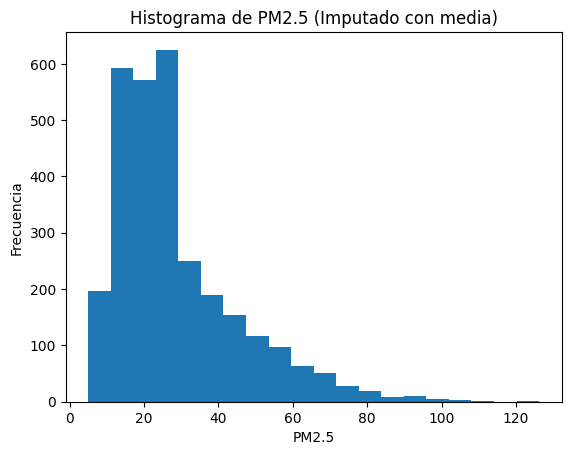

In [59]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df_media["PM2.5"], bins=20)
plt.title("Histograma de PM2.5 (Imputado con media)")
plt.xlabel("PM2.5")
plt.ylabel("Frecuencia")
plt.show()


<Figure size 640x480 with 0 Axes>

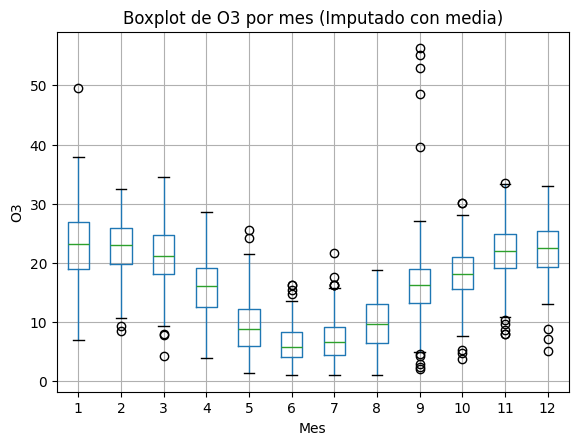

In [60]:
plt.figure()
df_media.boxplot(column="O3", by="mes")
plt.title("Boxplot de O3 por mes (Imputado con media)")
plt.suptitle("")
plt.xlabel("Mes")
plt.ylabel("O3")
plt.show()


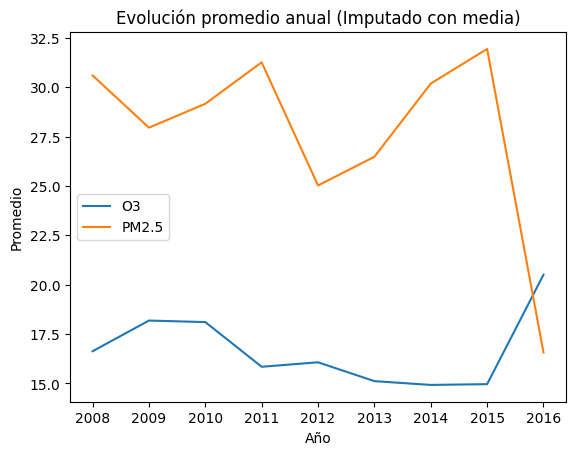

In [61]:
prom_media = df_media.groupby("año")[["O3", "PM2.5"]].mean()

plt.figure()
plt.plot(prom_media.index, prom_media["O3"], label="O3")
plt.plot(prom_media.index, prom_media["PM2.5"], label="PM2.5")
plt.title("Evolución promedio anual (Imputado con media)")
plt.xlabel("Año")
plt.ylabel("Promedio")
plt.legend()
plt.show()

#### Limpieza drop

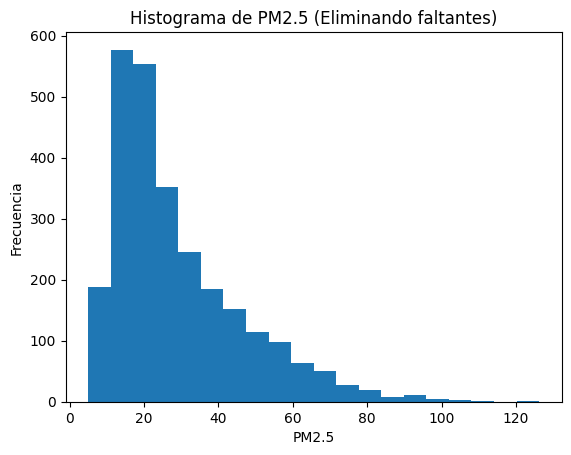

In [62]:
plt.figure()
plt.hist(df_drop["PM2.5"], bins=20)
plt.title("Histograma de PM2.5 (Eliminando faltantes)")
plt.xlabel("PM2.5")
plt.ylabel("Frecuencia")
plt.show()

<Figure size 640x480 with 0 Axes>

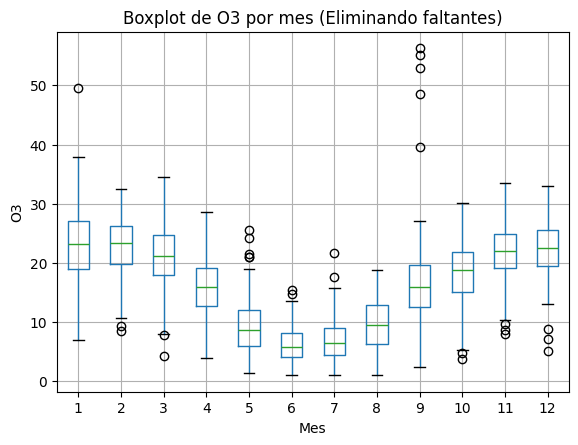

In [63]:
plt.figure()
df_drop.boxplot(column="O3", by="mes")
plt.title("Boxplot de O3 por mes (Eliminando faltantes)")
plt.suptitle("")
plt.xlabel("Mes")
plt.ylabel("O3")
plt.show()

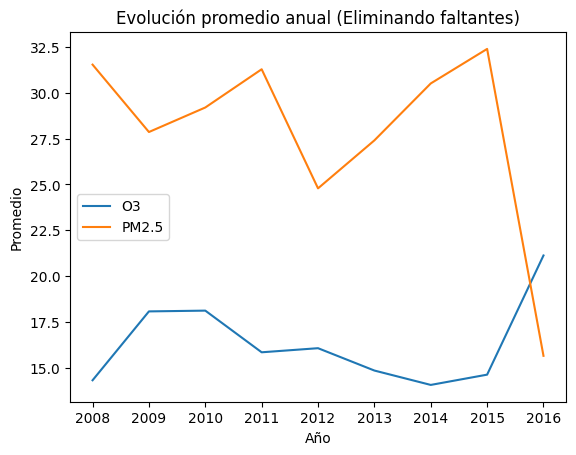

In [64]:
prom_drop = df_drop.groupby("año")[["O3", "PM2.5"]].mean()

plt.figure()
plt.plot(prom_drop.index, prom_drop["O3"], label="O3")
plt.plot(prom_drop.index, prom_drop["PM2.5"], label="PM2.5")
plt.title("Evolución promedio anual (Eliminando faltantes)")
plt.xlabel("Año")
plt.ylabel("Promedio")
plt.legend()
plt.show()

### Mision 4: categorizacion

In [65]:
df_media["Environmental_risk"] = df_media["Environmental_risk"].str.lower() # para homogeneizar
df_drop["Environmental_risk"] = df_drop["Environmental_risk"].str.lower()

In [66]:
def calcular_umbral(df):
    return {
        "O3_bajo": df["O3"].quantile(0.33),
        "O3_alto": df["O3"].quantile(0.66),
        "PM_bajo": df["PM2.5"].quantile(0.33),
        "PM_alto": df["PM2.5"].quantile(0.66),
    }

In [67]:
def clasificar(row, umbral):
    
    if row["O3"] >= umbral["O3_alto"] or row["PM2.5"] >= umbral["PM_alto"]:
        return "alto"
    
    elif row["O3"] <= umbral["O3_bajo"] and row["PM2.5"] <= umbral["PM_bajo"]:
        return "bajo"
    
    else:
        return "medio"

Vamos a ver value counts de environmental_risk para ver cuántos "alto", "medio" y "bajo" hay en cada df

In [68]:
df_media.value_counts("Environmental_risk")

Environmental_risk
medio      1605
bajo        750
nulo        134
alto        106
extremo      61
Name: count, dtype: int64

Los que sale como "nulo", los trataremos como nan, pero hay que llevarlos a eso para que pandas lo identifique

In [69]:
for df_ in [df_media, df_drop]:
    df_["Environmental_risk"] = df_["Environmental_risk"].replace("nulo", pd.NA)

#### Limpieza media

In [70]:
df_media.isna().sum()

Year                    0
Month                   0
Day                     0
O3                      0
PM2.5                   0
Environmental_risk    462
fecha                   0
año                     0
mes                     0
dtype: int64

In [71]:
for df_ in [df_media, df_drop]:
    
    umbral = calcular_umbral(df_)
    
    mask = df_["Environmental_risk"].isna() # el mask es netamente para solo modificar las filas que tienen NaN en "Environmental_risk"
    
    df_.loc[mask, "Environmental_risk"] = df_[mask].apply(
        lambda row: clasificar(row, umbral), axis=1 # aplica la función clasificar a cada fila que tiene NaN en "Environmental_risk"
    )

In [72]:
df_media.isna().sum()

Year                  0
Month                 0
Day                   0
O3                    0
PM2.5                 0
Environmental_risk    0
fecha                 0
año                   0
mes                   0
dtype: int64

In [73]:
df_media["Environmental_risk"].value_counts()

Environmental_risk
medio      1866
bajo        753
alto        304
extremo      61
Name: count, dtype: int64

In [74]:
df_drop.isna().sum()

Year                  0
Month                 0
Day                   0
O3                    0
PM2.5                 0
Environmental_risk    0
fecha                 0
año                   0
mes                   0
dtype: int64

In [75]:
df_drop["Environmental_risk"].value_counts()

Environmental_risk
medio      1681
bajo        751
alto        163
extremo      61
Name: count, dtype: int64

### Mision 5: analisis temporal avanzado

In [76]:
def obtener_estacion(mes):
    if mes in [12, 1, 2]:
        return "verano"
    elif mes in [3, 4, 5]:
        return "otoño"
    elif mes in [6, 7, 8]:
        return "invierno"
    else:
        return "primavera"

In [77]:
for df_ in [df_media, df_drop]:
    df_["estacion"] = df_["mes"].apply(obtener_estacion)

Luego agrupamos por año y estación

In [78]:
prom = df_media.groupby(["año", "estacion"])[["O3", "PM2.5"]].mean().reset_index()

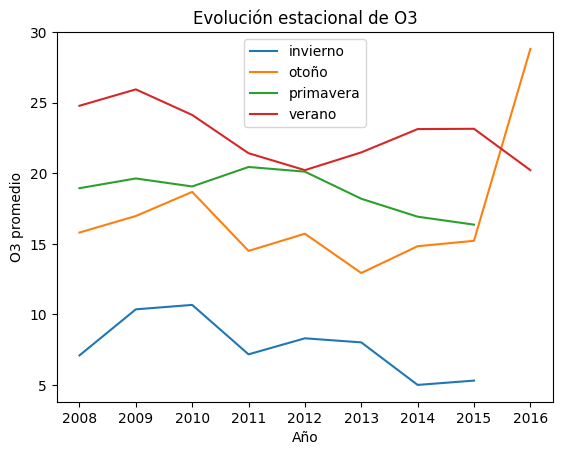

In [79]:
plt.figure()

for estacion in prom["estacion"].unique():
    data = prom[prom["estacion"] == estacion]
    plt.plot(data["año"], data["O3"], label=estacion)

plt.title("Evolución estacional de O3")
plt.xlabel("Año")
plt.ylabel("O3 promedio")
plt.legend()
plt.show()

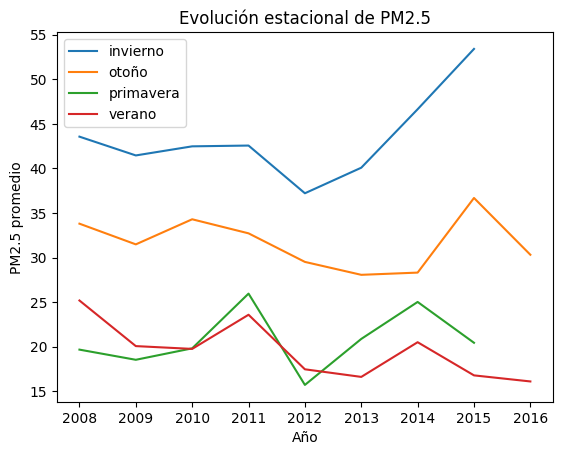

In [80]:
plt.figure()

for estacion in prom["estacion"].unique():
    data = prom[prom["estacion"] == estacion]
    plt.plot(data["año"], data["PM2.5"], label=estacion)

plt.title("Evolución estacional de PM2.5")
plt.xlabel("Año")
plt.ylabel("PM2.5 promedio")
plt.legend()
plt.show()

### Mision 6: deteccion de anomalias

In [81]:
def detectar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return (df[columna] < lower) | (df[columna] > upper)

In [82]:
outliers_O3 = detectar_outliers(df_media, "O3")
outliers_PM = detectar_outliers(df_media, "PM2.5")

In [83]:
outliers_total = outliers_O3 | outliers_PM # esto es "o" lógico, es decir, es True si es outlier en O3 o en PM2.5
outliers_total

0       False
1       False
2       False
3       False
4       False
        ...  
2979    False
2980    False
2981    False
2982    False
2983    False
Length: 2984, dtype: bool

In [84]:
outliers_total.value_counts()

False    2830
True      154
Name: count, dtype: int64

In [85]:
df_outliers = df_media[outliers_total].copy()

In [86]:
df_outliers["año"].value_counts().sort_index()

año
2008    24
2009    12
2010    14
2011    18
2012     9
2013     5
2014    24
2015    48
Name: count, dtype: int64

In [87]:
df_outliers["estacion"].value_counts()

estacion
invierno     112
otoño         34
primavera      5
verano         3
Name: count, dtype: int64

El método IQR revela que estos no se distribuyen de manera uniforme en el tiempo. Particularmente, el año 2015 presenta una cantidad significativamente mayor de outliers Asimismo, se observa una fuerte concentración de valores atípicos en la estación de invierno, donde se puede pensar que el material particulado tiende a aumentar por la baja ventilación y mayor uso de calefacción. De este modo, los outliers identificados no corresponden necesariamente a errores, sino que reflejan fenómenos ambientales relevantes.

### Mision 7: transformacion y enriquecimiento de datos

In [88]:
df_drop = df_drop.copy()
df_drop = df_drop.sort_values("fecha")

In [89]:
df_drop["ratio_O3_PM25"] = df_drop["O3"] / df_drop["PM2.5"]

In [90]:
p95_O3 = df_drop["O3"].quantile(0.95)
p95_PM = df_drop["PM2.5"].quantile(0.95)

In [91]:
df_drop["extremo"] = (
    (df_drop["O3"] > p95_O3) | 
    (df_drop["PM2.5"] > p95_PM)
)

In [92]:
df_drop["grupo_extremo"] = (df_drop["extremo"] != df_drop["extremo"].shift()).cumsum()

df_drop["dias_consecutivos_extremos"] = (
    df_drop.groupby("grupo_extremo")["extremo"]
    .transform("sum")
)

In [93]:
df_drop["dia_semana"] = df_drop["fecha"].dt.day_name()

df_drop["fin_de_semana"] = df_drop["fecha"].dt.weekday >= 5

In [94]:
pivot = pd.pivot_table(
    df_drop,
    values=["O3", "PM2.5"],
    index="mes",
    columns="Environmental_risk",
    aggfunc="mean"
)

pivot

O3                                       PM2.5  \
Environmental_risk      alto       bajo    extremo      medio       alto   
mes                                                                        
1                   26.15908  10.170000        NaN  17.353421  20.864847   
2                        NaN  20.472920  28.683333  24.585056        NaN   
3                        NaN  18.042683  28.500000  23.477815        NaN   
4                        NaN  13.508889        NaN  16.205899        NaN   
5                        NaN   7.564000        NaN   9.380538        NaN   
6                        NaN   8.238235        NaN   6.088698        NaN   
7                        NaN  10.913889        NaN   6.544133        NaN   
8                        NaN  10.574146        NaN   9.435126        NaN   
9                        NaN  15.554167  47.975000  16.434839        NaN   
10                       NaN  16.772712        NaN  20.345233        NaN   
11                       NaN  20.084298  28.871875  23.109718        NaN   
12                       NaN  20.290000  29.088333  24.033026        NaN   

                                                     
Environmental_risk       bajo    extremo      medio  
mes                                                  
1                   13.460000        NaN  13.296842  
2                   14.361327  16.360556  25.846404  
3                   14.728171  17.110000  26.388824  
4                   15.458889        NaN  32.021124  
5                   13.992667        NaN  45.399641  
6                   13.955882        NaN  51.995256  
7                   12.557222        NaN  49.882267  
8                   14.184634        NaN  39.751859  
9                   13.349028  13.500000  30.354032  
10                  14.097203        NaN  24.620000  
11                  12.943884  14.954375  25.176197  
12                  14.160952  16.413750  24.586053

In [95]:
df_drop = df_drop.sort_values("fecha")

df_drop["O3_ma7"] = df_drop["O3"].rolling(window=7).mean()
df_drop["PM25_ma7"] = df_drop["PM2.5"].rolling(window=7).mean()

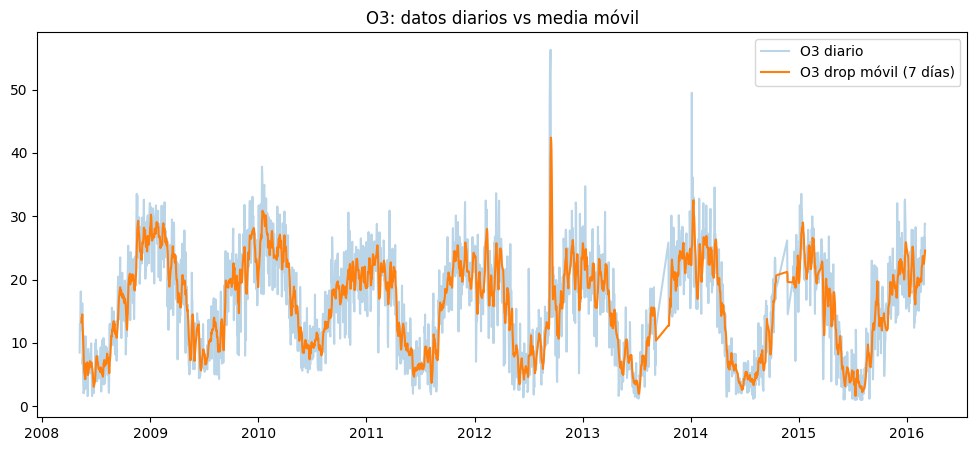

In [96]:
plt.figure(figsize=(12,5))

plt.plot(df_drop["fecha"], df_drop["O3"], alpha=0.3, label="O3 diario")
plt.plot(df_drop["fecha"], df_drop["O3_ma7"], label="O3 drop móvil (7 días)")

plt.legend()
plt.title("O3: datos diarios vs media móvil")
plt.show()

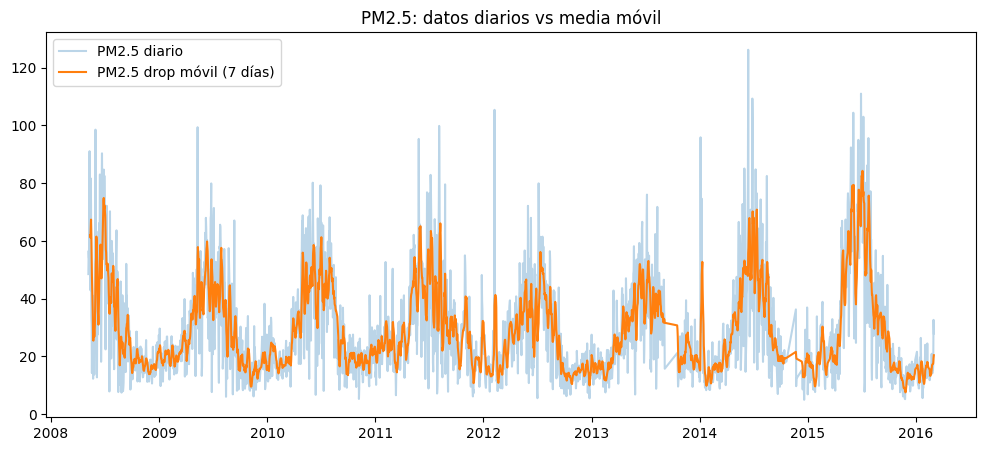

In [100]:
plt.figure(figsize=(12,5))

plt.plot(df_drop["fecha"], df_drop["PM2.5"], alpha=0.3, label="PM2.5 diario")
plt.plot(df_drop["fecha"], df_drop["PM25_ma7"], label="PM2.5 drop móvil (7 días)")

plt.legend()
plt.title("PM2.5: datos diarios vs media móvil")
plt.show()

Las transformaciones realizadas enriquecen el análisis al incorporar nuevas perspectivas sobre los datos. El ratio entre O3 y PM2.5 permite entender la relación entre contaminantes y la detección de días extremos consecutivos ayuda a identificar episodios prolongados de alta contaminación.

Además, las variables de día de la semana y fin de semana permiten observar patrones asociados a la actividad humana. La tabla dinámica facilita la comparación entre meses y niveles de riesgo, evidenciando posibles patrones estacionales.

Por último, la media móvil de 7 días suaviza la variabilidad diaria, permitiendo observar tendencias más claras en el tiempo.